In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import time
import re
from turtle import title

In [2]:
url = "https://www.jumia.ug/laptops/"
headers = {"User-Agent": "Mozilla/5.0"}

In [3]:

def get_page(url):
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "lxml")
    return soup

pages=50
all_products = []

for page in range(1, pages+1):
    url = f"https://www.jumia.ug/laptops/?page={page}#catalog-listing"
    soup = get_page(url)
    products = soup.find_all("article", class_="prd _fb col c-prd")

    for product in products:
        name = product.find('h3', class_='name')
        name = name.text if name else None

        price = product.find('div', class_='prc')
        price = price.text if price else None

        old_price = product.find('div', class_='old')
        old_price = old_price.text if old_price else None

        discount = product.find('div', class_='bdg _dsct _sm')
        discount = discount.text if discount else None

        product_data = {'name':name, 'price':price, 'old_price':old_price, 'discount':discount}

        all_products.append(product_data)
    time.sleep(1)

df = pd.DataFrame(all_products)
df.to_csv('jumia_products.csv', index=False)

In [4]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       2000 non-null   str  
 1   price      2000 non-null   str  
 2   old_price  1894 non-null   str  
 3   discount   1894 non-null   str  
dtypes: str(4)
memory usage: 62.6 KB


,name,price,old_price,discount
0,Refurbished HP Probook 640 Core I5 8GB Ram 500...,"UGX 559,000","UGX 1,400,000",60%
1,Latitude 11'' Inch 3180/3190 4GB RAM 128GB SSD...,"UGX 349,000","UGX 700,000",50%
2,"Travelmate,Intel Celeron.4GB RAM 64GB SSD, 12I...","UGX 329,000","UGX 650,000",49%
3,Hp Refurbished Probook TouchScreen X360 Intel ...,"UGX 440,000","UGX 980,019",55%
4,Hp RENEWED Probook 640 core i5 16GB Ram 500GB...,"UGX 599,000","UGX 1,200,000",50%


In [56]:
def data_cleaning(df):
    
    # Convert 'price' and 'discount' columns from boolean to string values
    df['price'] = df['price'].astype(str)
    df['discount'] = df['discount'].astype(str)

    # Removing data contains '-' from 'price' and 'discount' columns
    df = df[~df['price'].str.contains('-', na=False)]
    df = df[~df['discount'].str.contains('-', na=False)]
    
    # Removing 'UGX', ',' and '%' from 'price', 'old_price' and 'discount' columns
    df['price'] = df['price'].str.replace('UGX', '').str.replace(',', '').str.strip()
    df['old_price'] = df['old_price'].str.replace('UGX', '').str.replace(',', '').str.strip()
    
    # Convert 'price' and 'old_price' columns to numeric values
    df['price'] = df['price'].astype(float)
    df['old_price'] = df['old_price'].astype(float)

    return df

In [6]:
# Apply the data cleaning function to the new variable called data_jumia

data_jumia = pd.DataFrame(data_cleaning(df))
data_jumia.info()
data_jumia.head()

<class 'pandas.DataFrame'>
Index: 1992 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       1992 non-null   str    
 1   price      1992 non-null   float64
 2   old_price  1886 non-null   float64
 3   discount   1886 non-null   str    
dtypes: float64(2), str(2)
memory usage: 77.8 KB


,name,price,old_price,discount
0,Refurbished HP Probook 640 Core I5 8GB Ram 500...,559000.0,1400000.0,60%
1,Latitude 11'' Inch 3180/3190 4GB RAM 128GB SSD...,349000.0,700000.0,50%
2,"Travelmate,Intel Celeron.4GB RAM 64GB SSD, 12I...",329000.0,650000.0,49%
3,Hp Refurbished Probook TouchScreen X360 Intel ...,440000.0,980019.0,55%
4,Hp RENEWED Probook 640 core i5 16GB Ram 500GB...,599000.0,1200000.0,50%


In [35]:
# Creating new columns for prices in USD using exchange rate in 1:3750 of USD:UGX

data_jumia["price_usd_$"] = (data_jumia["price"] / 3750).astype(float).round(2) 
data_jumia["old_price_usd_$"] = (data_jumia["old_price"] / 3750).astype(float).round(2)

In [32]:
# Using describe () method to get summary statistics for the 'price' and 'old_price' columns
data_jumia[['price_usd_$', 'old_price_usd_$']].describe().round()

,price_usd_$,old_price_usd_$
count,1566.0,1499.0
mean,236.0,398.0
std,238.0,796.0
min,80.0,115.0
25%,128.0,213.0
50%,160.0,293.0
75%,240.0,400.0
max,4000.0,26667.0


In [58]:
# Extracting RAM information from the 'name' column
def extract_ram(name):
    if not isinstance(name, str):
        return None
    
    match = re.search(r'(\d+)\s?GB\s?RAM', name, re.IGNORECASE)
    if match:
        return int(match.group(1))
    return None


# Extracting (storage information) from the 'name' column
def extract_storage(name):
    if not isinstance(name, str):
        return None
    
    match = re.search(r'(\d+)\s?(GB|TB)', name, re.IGNORECASE)
    if match:
        size = int(match.group(1))
        unit = match.group(2).upper()
        
        if unit == "TB":
            size *= 1000  # convert to GB
            
        return size
    return None


# Extracting storage type (SSD or HDD) from the 'name' column
def extract_storage_type(name):
    if not isinstance(name, str):
        return None
    
    if "ssd" in name.lower():
        return "SSD"
    elif "hdd" in name.lower():
        return "HDD"
    
    return None

# Extracting CPU information from the 'name' column
def extract_cpu(title):
    if not isinstance(title, str):
        return None

    title = title.lower()

    if "i3" in title:
        return "i3"
    elif "i5" in title:
        return "i5"
    elif "i7" in title:
        return "i7"
    elif "ryzen 3" in title:
        return "Ryzen 3"
    elif "ryzen 5" in title:
        return "Ryzen 5"
    elif "ryzen 7" in title:
        return "Ryzen 7"

    return None


# Extracting (model) information from the 'name' column
brands = ["hp", "dell", "lenovo", "asus", "acer", "apple", 
          "ageneral", "duslang", "Foam Cleaner", "generic"]

def extract_model(name):
    if not isinstance(name, str):
        return None
    
    name_clean = re.sub(r'[^\w\s]', ' ', name.lower())
    words = name_clean.split()

    model_words = []
    found_brand = False

    for word in words:
        if word in brands:
            found_brand = True
        
        if not found_brand:
            continue
        
        if re.search(r'\d+gb|\d+tb|ram|ssd|hdd|intel|core', word):
            break
        
        model_words.append(word)

    if len(model_words) >= 2:
        return " ".join(model_words).title()
    
    return None;

In [ ]:
# Applying the extraction functions to create new columns in the DataFrame
data_jumia["ram_gb"] = data_jumia["name"].apply(extract_ram)
data_jumia["storage_gb"] = data_jumia["name"].apply(extract_storage)
data_jumia["storage_type"] = data_jumia["name"].apply(extract_storage_type)
data_jumia["cpu"] = data_jumia["name"].apply(extract_cpu)
data_jumia["model"] = data_jumia["name"].apply(extract_model)

data_jumia.head()


data_jumia.to_csv('cleaned_jumia_products.csv', index=False)

In [ ]:
# Checking for missing values in the new columns

ram = data_jumia['ram_gb'].isna().sum()
storage = data_jumia['storage_gb'].isna().sum()
storage_type = data_jumia['storage_type'].isna().sum()
cpu = data_jumia['cpu'].isna().sum()
model = data_jumia['model'].isna().sum()

# Print the number of missing values for each column
print(f"Missing RAM values: {ram}")
print(f"Missing Storage values: {storage}")
print(f"Missing Storage Type values: {storage_type}")
print(f"Missing CPU values: {cpu}")
print(f"Missing Model values: {model}")

Missing RAM values: 287
Missing Storage values: 49
Missing Storage Type values: 229
Missing CPU values: 753
Missing Model values: 1293


In [ ]:
# Removing the 'model' and 'cpu' columns cause they have a high number of missing values
#data_jumia = data_jumia.drop(columns=["model", "cpu", 'name', 'price', 'old_price'])

# Removing rows with missing values in 'ram_gb', 'storage_gb', and 'storage_type' columns
data_jumia = data_jumia.dropna(subset=["ram_gb", "storage_gb", "storage_type"])

# Removing rows with more than 100 ram from the 'ram_gb' column
data_jumia = data_jumia[data_jumia['ram_gb'] <= 100]

In [69]:
data_jumia.head()

,discount,ram_gb,storage_gb,storage_type,price_usd_$,old_price_usd_$
0,60%,8,8,HDD,149.07,373.33
1,50%,4,4,SSD,93.07,186.67
2,49%,4,4,SSD,87.73,173.33
3,55%,4,4,SSD,117.33,261.34
4,50%,16,16,HDD,159.73,320.00


In [86]:
# Grouping the data by 'ram_gb' and calculating the average price in USD for each RAM size

price_by_ram = data_jumia.groupby('ram_gb').agg(
    {
        'price_usd_$':['mean','max','min'],
        'old_price_usd_$':['mean','max','min']
    }
).round(2)

price_by_ram

price_usd_$                  old_price_usd_$                  
              mean      max     min            mean       max     min
ram_gb                                                               
2           120.00   120.00  120.00          173.33    173.33  173.33
4           129.02   693.33   79.73          238.89   1757.33  114.67
6           164.80   186.40  148.27          371.55    450.66  266.67
8           248.84  4000.00  101.33          456.26  26666.67  146.67
12          199.26   445.33  133.07          358.45    610.67  200.00
16          424.35  2000.00  127.47          562.74   2666.67  186.40
32          671.89  1026.67  399.73          912.00   1333.33  560.00

In [84]:
# Grouping the data by 'storage_type' and calculating summary statistics for 'price' and 'old_price' columns

data_jumia.groupby('storage_type').agg(
    {
        'price_usd_$':['mean','max','min'],
        'old_price_usd_$':['mean','max','min']
    }
).round(2)

price_usd_$                 old_price_usd_$                  
                    mean      max    min            mean       max     min
storage_type                                                              
HDD               170.11  1013.33  92.00          386.07  26666.67  122.67
SSD               266.32  4000.00  79.73          402.99   9333.33  114.67

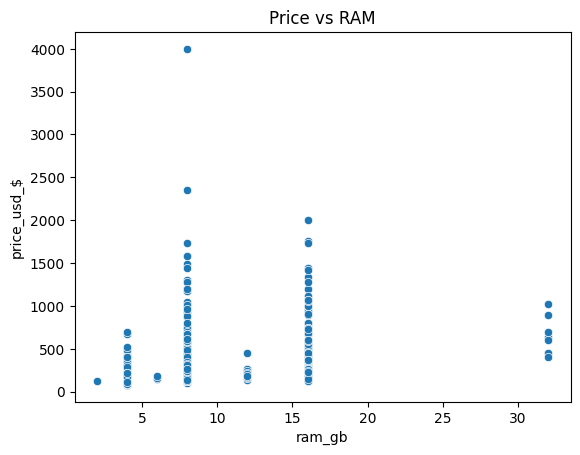

In [100]:
# Drawing a boxplot to visualize the relationship between RAM and price

sns.scatterplot(x="ram_gb", y="price_usd_$", data=data_jumia)
plt.title("Price vs RAM")
plt.show()

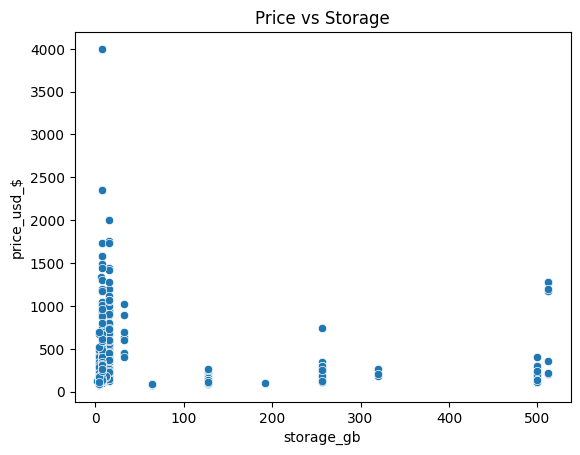

In [98]:
# drawing a boxplot to visualize the relationship between storage and price

sns.scatterplot(x="storage_gb", y="price_usd_$", data=data_jumia)
plt.title("Price vs Storage")
plt.show()

In [ ]:
# Calculating the correlation between 'price_usd_$', 'ram_gb', and 'storage_gb' columns
data_jumia[["price_usd_$", "ram_gb", "storage_gb"]].corr()

,price_usd_$,ram_gb,storage_gb
price_usd_$,1.000000,0.403815,0.008347
ram_gb,0.403815,1.000000,-0.066562
storage_gb,0.008347,-0.066562,1.000000


Text(0.5, 1.0, 'Price vs RAM and Storage')

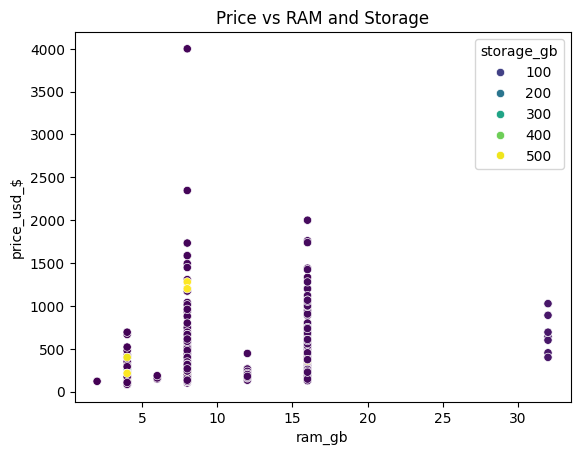

In [103]:
# Drawing a scatter plot to visualize the correlation between RAM, Storage and price

sns.scatterplot(x="ram_gb", y="price_usd_$", data=data_jumia, hue="storage_gb", palette="viridis")
plt.title("Price vs RAM and Storage")
